In [1]:
from sentence_transformers import SentenceTransformer
import tqdm as notebook_tqdm
import torch
from tqdm import tqdm
# Load the embedding model
model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
print("Model loaded!")

/home/tom/bre-fine-arts/Fine-Arts-Main/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 12661.21it/s]


Model loaded!


In [2]:
# Import required libraries for image downloading and display
import requests
from requests.auth import HTTPBasicAuth
from io import BytesIO
from PIL import Image as PILImage
from IPython.display import display
import os
from dotenv import load_dotenv
load_dotenv()

# Nextcloud configuration
NC_HOST = os.getenv("DB_HOST")
NC_ACC = os.getenv("NC_ACC")
NC_PASS = os.getenv("NC_PASS")

print(f"Nextcloud host: {NC_HOST}")
print(f"Nextcloud account: {NC_ACC}")

Nextcloud host: 192.168.0.150
Nextcloud account: Tom


In [3]:
def get_images(file_id, file_path):
    """
    Download and display a thumbnail/preview for a file from Nextcloud.
    
    Args:
        file_id: The Nextcloud file ID
        file_path: The path to the file on the Nextcloud server
    
    Returns:
        PIL.Image: The resized 256x256 PIL Image
    """
    server_url = f'http://{NC_HOST}:8080/remote.php/dav/files/{NC_ACC}'
    preview_url = f'http://{NC_HOST}:8080/core/preview?fileId={file_id}&x=1080&y=1080'
    username = NC_ACC
    password = NC_PASS

    file_url = f"{server_url}{file_path}"

    response = requests.get(preview_url, auth=HTTPBasicAuth(username, password), stream=True)
 
    if response.status_code == 200:
        file_in_memory = BytesIO()
        for chunk in response.iter_content(chunk_size=1024):
            if chunk:
                file_in_memory.write(chunk)
        file_in_memory.seek(0)
        img = PILImage.open(file_in_memory)
        img = img.resize((256, 256))
        display(img)
    elif response.status_code == 404:
        try:
            response = requests.get(file_url, auth=HTTPBasicAuth(username, password), stream=True)
            file_in_memory = BytesIO()
            for chunk in response.iter_content(chunk_size=1024):
                if chunk:
                    file_in_memory.write(chunk)
            file_in_memory.seek(0)
            source_img = PILImage.open(file_in_memory)
            img_display = source_img.resize((256, 256))
            display(img_display)
        except Exception as e:
            print(f"Failed to download file. Exception: {e}")
    else:
        print(f"Failed to download file. Status code: {response.status_code}")
    
    try:
        import gc
        del file_in_memory
        gc.collect()
    except:
        pass
    return img

In [4]:
from sqlalchemy import create_engine, MetaData, Table, select, insert
from sqlalchemy.exc import SQLAlchemyError
import pandas as pd

def create_db_connection():
    load_dotenv()
    DB_HOST = os.getenv("DB_HOST")
    DB_NAME = os.getenv("DB_NAME")
    DB_USER = os.getenv("DB_USER")
    DB_PASSWORD = os.getenv("DB_PASSWORD")
    engine = create_engine('postgresql+pg8000://'+DB_USER+':'+DB_PASSWORD+'@'+DB_HOST+':5432/'+DB_NAME)
    return engine

def get_tags():
    try:
        engine = create_db_connection()
        df_systag = pd.read_sql_table('oc_systemtag', engine)
        df_tagmap = pd.read_sql_table('oc_systemtag_object_mapping', engine)
    except SQLAlchemyError as e:
        print(f"An error occurred: {e}")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")
    return df_systag, df_tagmap

In [5]:
print("Loading tags from database...")
df_systag, df_tagmap = get_tags()
print(f"Loaded {len(df_systag)} tags and {len(df_tagmap)} mappings")

Loading tags from database...
Loaded 766 tags and 21533 mappings


In [6]:
# ============================================
# Document Aggregation Approach
# ============================================
# Build a document for each file by aggregating all its tags.
# This creates a richer semantic representation per file.

def build_file_documents(df_systag, df_tagmap):
    """
    Build a dictionary mapping file IDs to their aggregated tag documents.
    
    Args:
        df_systag: DataFrame with tag id and name columns
        df_tagmap: DataFrame with systemtagid and objectid columns
    
    Returns:
        dict: {file_id: "tag1 tag2 tag3 ..."}
    """
    # Merge tagmap with tag names
    tagmap_with_names = df_tagmap.merge(
        df_systag[['id', 'name']],
        left_on='systemtagid',
        right_on='id',
        how='inner'
    )
    
    # Group by file_id (objectid) and aggregate tag names
    file_docs = {}
    for file_id, group in tagmap_with_names.groupby('objectid'):
        # Sort tags alphabetically for consistency, deduplicate
        tags = sorted(set(group['name'].tolist()))
        file_docs[str(file_id)] = ' '.join(tags)
    
    return file_docs, tagmap_with_names

file_documents, tagmap_with_names = build_file_documents(df_systag, df_tagmap)
print(f"Built {len(file_documents)} file documents")

# Show some examples
print("\nExample file documents:")
for i, (file_id, doc) in enumerate(list(file_documents.items())[:5]):
    print(f"  File {file_id}: '{doc}'")

Built 1517 file documents

Example file documents:
  File 1000: 'abstract design element eye graphic icon iconography illustration minimalist modern orange red simplistic symbol visual'
  File 10001: 'botanical design digital floral graphic green greenish illustration inspire leaflike leave nature plant tropical'
  File 10017: 'abstract circle colorful composition contemporary form geometric minimalist modern semi shape'
  File 1003: 'background design evil eye folk graphic icon minimalist modern mystery mystic symbol symbolism yellow'
  File 10035: 'abstract artistic blue botanical composition digital floral geometric green inspire minimalist modern nature pattern teal textured'


In [7]:
# ============================================
# TF-IDF Weighted Document Embeddings
# ============================================
# Apply TF-IDF weighting to tags so rare/discriminative tags
# contribute more to the embedding than common tags.

from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

print("Applying TF-IDF weighting to documents...")

# Get document texts in consistent order
doc_ids = list(file_documents.keys())
doc_texts = [file_documents[fid] for fid in doc_ids]

# Fit TF-IDF vectorizer on all documents
tfidf_vectorizer = TfidfVectorizer(token_pattern=r'(?u)\b\w+\b')
tfidf_matrix = tfidf_vectorizer.fit_transform(doc_texts)

print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")
print(f"Vocabulary size: {len(tfidf_vectorizer.vocabulary_)}")

# Convert TF-IDF weighted sparse matrix back to dense text
# by repeating tags proportional to their TF-IDF scores
def tfidf_weighted_docs(tfidf_matrix, doc_ids, doc_texts, repeat_factor=3):
    """
    Create weighted document strings by repeating tags based on TF-IDF scores.
    
    Args:
        tfidf_matrix: Sparse TF-IDF matrix (n_docs x n_terms)
        doc_ids: List of document IDs
        doc_texts: List of original document texts
        repeat_factor: Maximum repeats for high-scoring terms
    
    Returns:
        list: Weighted document strings
    """
    vocabulary = tfidf_vectorizer.vocabulary_
    inv_vocab = {v: k for k, v in vocabulary.items()}
    
    weighted_docs = []
    for i in range(tfidf_matrix.shape[0]):
        row = tfidf_matrix.getrow(i)
        indices = row.nonzero()[1]
        scores = row.data
        
        # Sort by TF-IDF score descending
        sorted_order = np.argsort(scores)[::-1]
        indices = indices[sorted_order]
        scores = scores[sorted_order]
        
        # Repeat tags based on score (higher score = more repeats)
        weighted_tags = []
        for idx, score in zip(indices, scores):
            tag = inv_vocab[idx]
            # Scale repeats: min 1, max repeat_factor based on score
            repeats = max(1, int(score * repeat_factor))
            weighted_tags.extend([tag] * repeats)
        
        weighted_docs.append(' '.join(weighted_tags))
    
    return weighted_docs

# Create weighted documents (repeat_factor=3 means top tags repeat ~3x)
weighted_doc_texts = tfidf_weighted_docs(tfidf_matrix, doc_ids, doc_texts, repeat_factor=3)

# Show comparison
print("\nOriginal vs TF-IDF Weighted Documents:")
for i in range(min(5, len(doc_ids))):
    print(f"\n  File {doc_ids[i]}:")
    print(f"    Original:   '{doc_texts[i][:100]}...'")
    print(f"    Weighted:   '{weighted_doc_texts[i][:100]}...'")

Applying TF-IDF weighting to documents...
TF-IDF matrix shape: (1517, 766)
Vocabulary size: 766

Original vs TF-IDF Weighted Documents:

  File 1000:
    Original:   'abstract design element eye graphic icon iconography illustration minimalist modern orange red simpl...'
    Weighted:   'element iconography icon eye symbol simplistic graphic visual illustration red orange minimalist des...'

  File 10001:
    Original:   'botanical design digital floral graphic green greenish illustration inspire leaflike leave nature pl...'
    Weighted:   'leaflike greenish plant tropical inspire graphic digital leave illustration botanical floral green n...'

  File 10017:
    Original:   'abstract circle colorful composition contemporary form geometric minimalist modern semi shape...'
    Weighted:   'semi semi form circle contemporary shape minimalist geometric colorful modern composition abstract...'

  File 1003:
    Original:   'background design evil eye folk graphic icon minimalist modern mys

In [8]:
# ============================================
# Pre-compute TF-IDF Weighted Document Embeddings
# ============================================

print("Encoding TF-IDF weighted documents...")
tfidf_doc_embeddings = model.encode(weighted_doc_texts)
print(f"Encoded {len(tfidf_doc_embeddings)} weighted documents")
print(f"Embedding shape: {tfidf_doc_embeddings.shape}")

Encoding TF-IDF weighted documents...
Encoded 1517 weighted documents
Embedding shape: (1517, 384)


In [9]:
# ============================================
# TF-IDF Weighted Document Similarity Search
# ============================================

def search_files_by_tfidf_document_similarity(query, top_k=10):
    """
    Search for files using TF-IDF weighted document embeddings.
    
    Args:
        query: Natural language search query
        top_k: Number of top results to return
    
    Returns:
        DataFrame with file_id, document, similarity score, ranked
    """
    # Encode the query
    query_embedding = model.encode(query, prompt_name="query")
    
    # Compute cosine similarity between query and all weighted document embeddings
    similarity = model.similarity(
        torch.tensor(query_embedding).unsqueeze(0),
        torch.tensor(tfidf_doc_embeddings)
    )
    
    # Get top-k indices
    top_indices = similarity[0].argsort(descending=True)[:top_k]
    
    # Build results DataFrame
    results = pd.DataFrame({
        'file_id': [doc_ids[i] for i in top_indices],
        'document': [doc_texts[i] for i in top_indices],
        'weighted_document': [weighted_doc_texts[i] for i in top_indices],
        'similarity': similarity[0][top_indices].cpu().numpy()
    })
    
    return results

print("TF-IDF weighted search function ready!")

TF-IDF weighted search function ready!


In [10]:
# ============================================
# Display Thumbnails for Search Results
# ============================================

def display_doc_search_thumbnails(results, top_n):
    """
    Display thumbnails for the top N files from document search results.
    
    Args:
        results: DataFrame with file_id column
        top_n: Number of thumbnails to display (default 3)
    """
    if results.empty:
        print("No files found.")
        return
    
    print(f"\nDisplaying top {min(top_n, len(results))} thumbnails:")
    for i, row in results.head(top_n).iterrows():
        file_id = row['file_id']
        print(f"Thumbnail {i+1}: File ID = {file_id}, Similarity = {row['similarity']:.4f}")
        file_path = "/images/"
        try:
            img = get_images(file_id, file_path)
        except Exception as e:
            print(f"  Failed to load image: {e}")
        print()

  0%|          | 0/3 [00:00<?, ?it/s]


Query: 'A painting with green landscape scene'

Top 10 results:
file_id                                                                                                                       document  similarity
    741                                                             abstract colorful composition landscape minimalist modern painting    0.687984
   5211                                                   abstract colorful composition expressionism landscape modern nature painting    0.678218
   5984        abstract artwork blue cloud contemporary fine green impressionism landscape modern mountain nature painting sky texture    0.646179
   6100     abstract brown brushstroke composition green impressionism landscape nature outdoors painting scenery tree wildlife yellow    0.646083
   5070                                                    abstract colorful composition expressionism field landscape modern painting    0.645456
   5712     abstract colorful composition contemporar

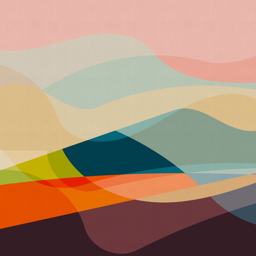


Thumbnail 2: File ID = 5211, Similarity = 0.6782


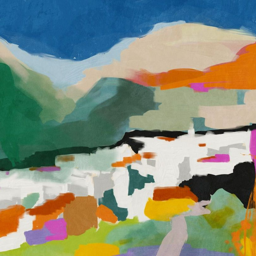


Thumbnail 3: File ID = 5984, Similarity = 0.6462


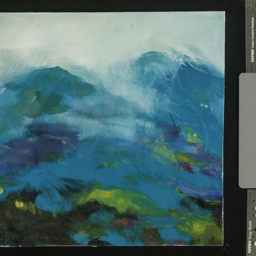

 33%|███▎      | 1/3 [00:01<00:03,  1.92s/it]



Query: 'portrait of a person'

Top 10 results:
file_id                                                                                                                                  document  similarity
   5171               abstract artwork colorful contemporary figure flower green hat impressionism orange painting pink portrait red woman yellow    0.576064
   5294                          abstract colorful composition contemporary expressionism expressive figure impressionist modern painting vibrant    0.495832
   5227                   abstract artwork colorful composition contemporary expressionism figure impressionism landscape modern painting vibrant    0.489742
   5191                          abstract artwork colorful composition contemporary expressionism expressive figure impressionism modern painting    0.482992
   4027                    abstract black contemporary dramatic emotional expressive figure floral nature pink portrait red soft surrealism white    0.476393
   

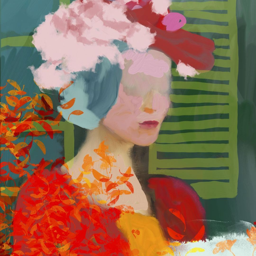


Thumbnail 2: File ID = 5294, Similarity = 0.4958


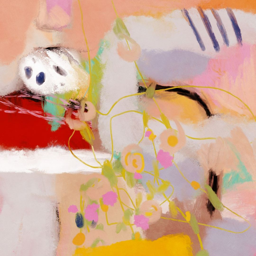


Thumbnail 3: File ID = 5227, Similarity = 0.4897


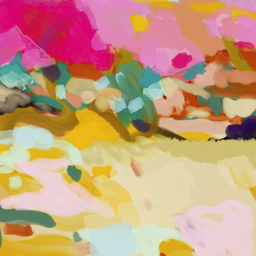

 67%|██████▋   | 2/3 [00:03<00:01,  1.87s/it]



Query: 'abstract art with bright colors'

Top 10 results:
file_id                                                                                                    document  similarity
   7787                                          abstract artwork colorful composition contemporary modern painting    0.788491
   9771                                          abstract artwork colorful composition contemporary modern painting    0.788491
    924                                   abstract artwork colorful composition contemporary modern painting visual    0.780385
   8111    abstract blue colorful composition cool geometric minimalist modern orange painting pink red warm yellow    0.778277
   5418                                           abstract colorful composition contemporary design modern painting    0.777432
   1298                                                 abstract artwork colorful design minimalist modern painting    0.771582
   1269                                     

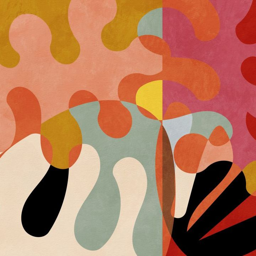


Thumbnail 2: File ID = 9771, Similarity = 0.7885


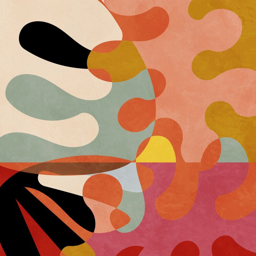


Thumbnail 3: File ID = 924, Similarity = 0.7804


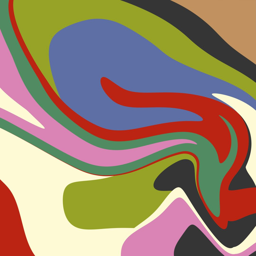

100%|██████████| 3/3 [00:05<00:00,  1.87s/it]

In [11]:
# ============================================
# Run TF-IDF Weighted Document Search Tests
# ============================================

test_queries = [
    "A painting with green landscape scene",
    "portrait of a person",
    "abstract art with bright colors",
]

for query in tqdm(test_queries):
    print(f"\n{'='*60}")
    print(f"Query: '{query}'")
    print(f"{'='*60}")
    
    # Search using TF-IDF weighted document similarity
    results = search_files_by_tfidf_document_similarity(query, top_k=10)
    
    print(f"\nTop 10 results:")
    print(results[['file_id', 'document', 'similarity']].to_string(index=False))
    
    # Display top 3 thumbnails
    display_doc_search_thumbnails(results, top_n=3)

  0%|          | 0/3 [00:00<?, ?it/s]


Query: 'coloful contemproary art for a wallpaper'

Top 10 results:
file_id                                                                                                                                                     document  similarity
   7091                                           abstract artistic circle colorful composition decor design geometric home interior modern pastel pattern wallpaper    0.672036
   1399                                             abstract black circular colorful decor design geometric home modern pattern swirl texture wallpaper white yellow    0.667087
   9804                                           abstract artwork circle colorful cool decor design earthy geometric modern pattern textured vibrant wallpaper warm    0.663013
   1246                                         abstract artwork circle colorful composition decor design geometric home minimalist modern pattern vibrant wallpaper    0.660640
    647                                   backg

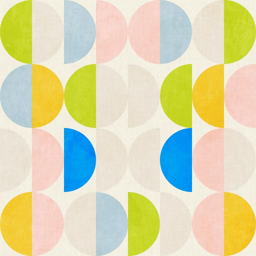


Thumbnail 2: File ID = 1399, Similarity = 0.6671


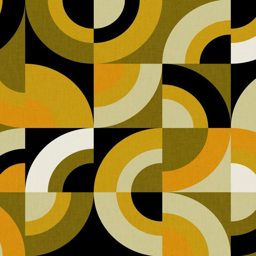


Thumbnail 3: File ID = 9804, Similarity = 0.6630


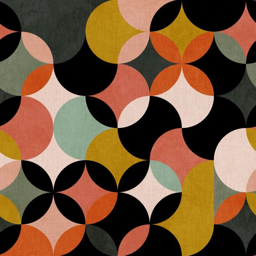


Thumbnail 4: File ID = 1246, Similarity = 0.6606


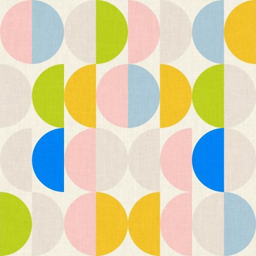


Thumbnail 5: File ID = 647, Similarity = 0.6558


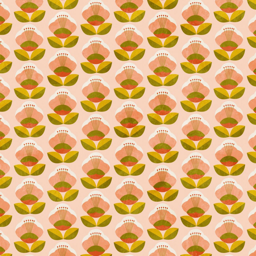

 33%|███▎      | 1/3 [00:02<00:05,  3.00s/it]



Query: 'greek villages'

Top 10 results:
file_id                                                                                                                                           document  similarity
   3844 architecture blue building cloud coastal greece house landscape mediterranean mountain nature painting residential scenic seaside sky street white    0.516087
    867                  architecture blue building dome flower greek mediterranean minimalist modern nature santorini seaside simplistic sky white yellow    0.403718
    934            architecture building cityscape colorful community composition drawing house housing illustration minimalist pastel rural urban village    0.340623
   6018                      abstract blue colorful day folk green impressionism landscape modern nature painting rural scene sunny vibrant village yellow    0.312374
   7346            architecture beige building cityscape composition drawing home house illustration minimalist silhouette

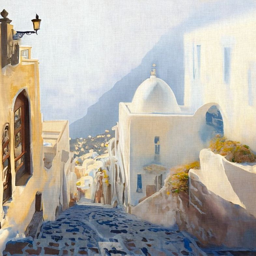


Thumbnail 2: File ID = 867, Similarity = 0.4037


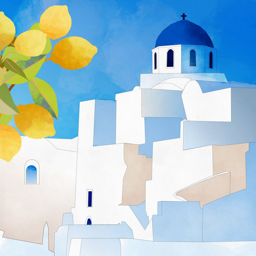


Thumbnail 3: File ID = 934, Similarity = 0.3406


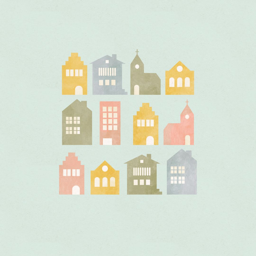


Thumbnail 4: File ID = 6018, Similarity = 0.3124


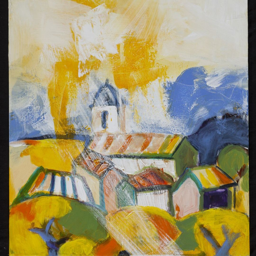


Thumbnail 5: File ID = 7346, Similarity = 0.2973


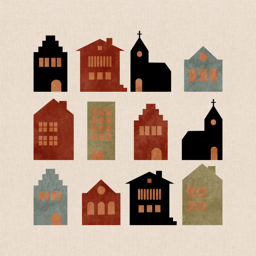

 67%|██████▋   | 2/3 [00:05<00:02,  3.00s/it]



Query: 'primarily green wallpaper patterns which are repetitive with flowers'

Top 10 results:
file_id                                                                                                                        document  similarity
   4084      background bloom blossom floral flower green impressionism leave life nature orange painting petal still texture wallpaper    0.725094
  11026                 botanical colorful decor design floral green home inspire interior leave nature organic pattern plant wallpaper    0.724271
   1272              brown composition decor decorative design flower green home illustration nature pattern sunflower wallpaper yellow    0.716361
   5018                         abstract colorful composition decor design green inspire nature organic pattern swirl texture wallpaper    0.708147
   4477                            botanical composition decor decorative foliage green home leave nature plant tropical wall wallpaper    0.700247
  12421        

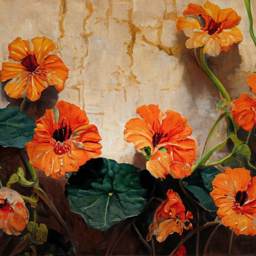


Thumbnail 2: File ID = 11026, Similarity = 0.7243


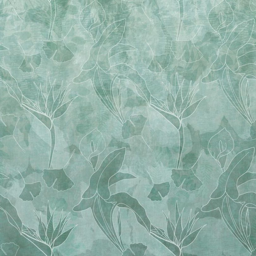


Thumbnail 3: File ID = 1272, Similarity = 0.7164


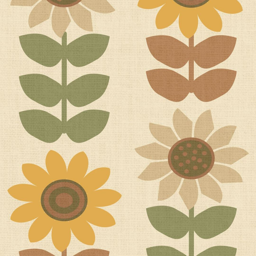


Thumbnail 4: File ID = 5018, Similarity = 0.7081


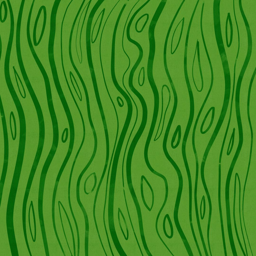


Thumbnail 5: File ID = 4477, Similarity = 0.7002


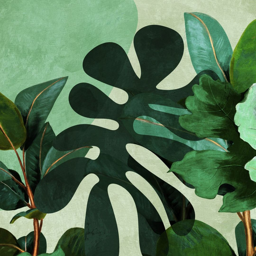

100%|██████████| 3/3 [00:09<00:00,  3.03s/it]

In [12]:
# ============================================
# Run TF-IDF Weighted Document Search Tests
# ============================================
test_queries = [
    "coloful contemproary art for a wallpaper",
    "greek villages",
    "primarily green wallpaper patterns which are repetitive with flowers",
]

for query in tqdm(test_queries):
    print(f"\n{'='*60}")
    print(f"Query: '{query}'")
    print(f"{'='*60}")
    
    # Search using TF-IDF weighted document similarity
    results = search_files_by_tfidf_document_similarity(query, top_k=10)
    
    print(f"\nTop 10 results:")
    print(results[['file_id', 'document', 'similarity']].to_string(index=False))
    
    # Display top 3 thumbnails
    display_doc_search_thumbnails(results, top_n=5)

  0%|          | 0/1 [00:00<?, ?it/s]


Query: 'show me lemmons!'

Top 10 results:
file_id                                                                                                                                            document  similarity
   5684                      abstract blot blue dreamy fluid green impressionist organic pastel peach pink purple soft splotch texture watercolor whimsical    0.221192
    588                                   abstract composition earth grass hills impressionist landscape mountain nature scenic sky sunset water watercolor    0.214600
    581                                  abstract artwork colorful composition impressionism impressionist landscape mountain nature sky tree vibrant vivid    0.211606
   6111                                            black blue landscape nature outdoor painting reflection scenic seasonal sky snow tree water white winter    0.210875
    721                                   avocado colorful design digital flat food fruit illustration life nature o

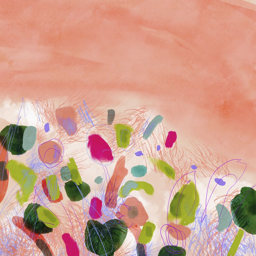


Thumbnail 2: File ID = 588, Similarity = 0.2146


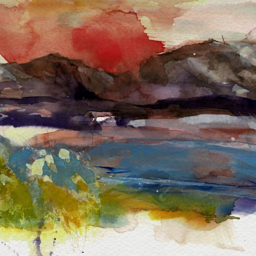


Thumbnail 3: File ID = 581, Similarity = 0.2116


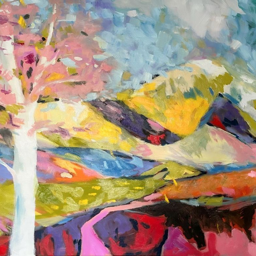


Thumbnail 4: File ID = 6111, Similarity = 0.2109


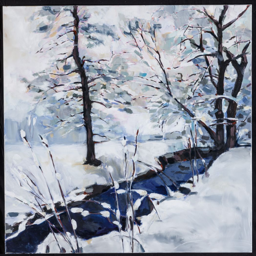


Thumbnail 5: File ID = 721, Similarity = 0.2086


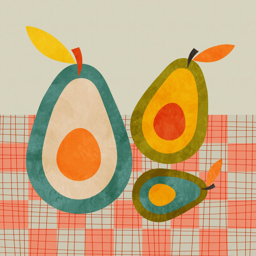

100%|██████████| 1/1 [00:03<00:00,  3.05s/it]

In [13]:
# ============================================
# Run TF-IDF Weighted Document Search Tests
# ============================================
test_queries = [
    "show me lemmons!",
]

for query in tqdm(test_queries):
    print(f"\n{'='*60}")
    print(f"Query: '{query}'")
    print(f"{'='*60}")
    
    # Search using TF-IDF weighted document similarity
    results = search_files_by_tfidf_document_similarity(query, top_k=10)
    
    print(f"\nTop 10 results:")
    print(results[['file_id', 'document', 'similarity']].to_string(index=False))
    
    # Display top 3 thumbnails
    display_doc_search_thumbnails(results, top_n=5)